In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Loading and exploring the dataset
df = pd.read_csv('car_fuel_efficiency_2026.csv')

display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           10000 non-null  int64  
 1   origin               10000 non-null  object 
 2   fuel_type            10000 non-null  object 
 3   drivetrain           10000 non-null  object 
 4   num_doors            10000 non-null  int64  
 5   engine_displacement  10000 non-null  int64  
 6   num_cylinders        10000 non-null  int64  
 7   horsepower           9123 non-null   float64
 8   vehicle_weight       10000 non-null  int64  
 9   acceleration         9736 non-null   float64
 10  fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(3), int64(5), object(3)
memory usage: 859.5+ KB


None

,model_year,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
count,10000.000000,10000.00000,10000.000000,10000.000000,9123.000000,10000.000000,9736.000000,10000.000000
mean,1999.549500,3.50400,2268.807000,6.035200,254.446016,4286.754000,18.888044,29.997700
std,14.207925,0.95209,183.447355,0.542578,22.844613,266.212491,1.279543,2.930245
min,1975.000000,2.00000,1590.000000,4.000000,171.000000,3320.000000,14.000000,19.800000
25%,1987.000000,3.00000,2150.000000,6.000000,239.000000,4110.000000,18.000000,28.000000
50%,2000.000000,4.00000,2270.000000,6.000000,254.000000,4280.000000,18.900000,30.000000
75%,2012.000000,4.00000,2390.000000,6.000000,270.000000,4470.000000,19.700000,31.900000
max,2024.000000,5.00000,3110.000000,8.000000,334.000000,5460.000000,23.800000,41.200000


In [3]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [4]:
cols_to_use = ['engine_displacement',
               'horsepower',
               'vehicle_weight',
               'model_year',
               'fuel_efficiency_mpg']

df = df[cols_to_use]
display(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  10000 non-null  int64  
 1   horsepower           9123 non-null   float64
 2   vehicle_weight       10000 non-null  int64  
 3   model_year           10000 non-null  int64  
 4   fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


None

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


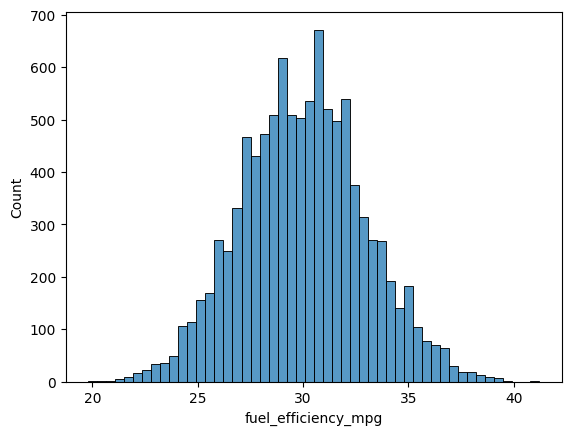

In [5]:
# EDA: Does `fuel_efficiency_mpg` have a long tail?
sns.histplot(df['fuel_efficiency_mpg'], bins=50);

In [6]:
# Q1. The column `horsepower` has missing values:
print(f'Number of rows missing horsepower: {df['horsepower'].isnull().sum()}')

Number of rows missing horsepower: 877


In [7]:
# Q2. Median of `horsepower`:
print(f'Median of `horsepower` column: {df['horsepower'].median()}')

Median of `horsepower` column: 254.0


In [8]:
# Prepare and split the dataset

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

In [9]:
# Split the target variable

y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

y_train.shape, y_val.shape, y_test.shape

((6000,), (2000,), (2000,))

In [10]:
# Delete target column from features dataframes

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [11]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,1900,239.0,3790,2015
1,2000,224.0,4380,1992
2,2330,286.0,4090,2022
3,2300,NaN,4150,1997
4,2340,269.0,4400,2001


In [12]:
df_train['model_year'].max(), df_train['model_year'].min()

(np.int64(2024), np.int64(1975))

In [13]:
# Q3. Linear regression to predict `fuel_efficiency_mpg`, 
# filling missing values for column `horsepower` in two ways:

# (1) Fill with 0
def prepare_X_fill_0(df):
    df = df.copy()
    df['horsepower'] = df['horsepower'].fillna(0)
    X = df.values
    
    return X

# (2) Fill with mean
mean_horsepower = df_train['horsepower'].mean()
print('Mean horsepower in training set:', mean_horsepower)

def prepare_X_fill_mean(df):
    df = df.copy()
    df['horsepower'] = df['horsepower'].fillna(mean_horsepower)
    X = df.values
    return X

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

def rmse(y, y_pred):
    return np.sqrt(((y - y_pred) ** 2).mean())

Mean horsepower in training set: 254.46338337605272


In [14]:
# (1)
X_train = prepare_X_fill_0(df_train)
w0, w = train_linear_regression(X_train, y_train) 

X_val = prepare_X_fill_0(df_val)
y_pred = w0 + X_val.dot(w)

rmse_fill_0 = rmse(y_val, y_pred).round(3)

# (2)
X_train = prepare_X_fill_mean(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X_fill_mean(df_val)
y_pred = w0 + X_val.dot(w)

rmse_fill_mean = rmse(y_val, y_pred).round(3)

print(f'RMSE when filling missing horsepower with 0: {rmse_fill_0}, \nwhen filling with mean: {rmse_fill_mean}')

RMSE when filling missing horsepower with 0: 2.205, 
when filling with mean: 2.202


In [15]:
# Q4. Linear regression with regularization parameter

def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [16]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X_fill_0(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r)
    X_val = prepare_X_fill_0(df_val)
    y_pred = w0 + X_val.dot(w)
    rmse_val = rmse(y_val, y_pred).round(4)
    
    print(f'r: {r}, RMSE = {rmse_val}')
    

r: 0, RMSE = 2.2053
r: 0.01, RMSE = 2.2058
r: 0.1, RMSE = 2.2241
r: 1, RMSE = 2.3492
r: 5, RMSE = 2.4094
r: 10, RMSE = 2.4195
r: 100, RMSE = 2.4292


In [17]:
# Q5. Standard deviation of RMSEs using different seeds

rmses = []

for s in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(s)
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_shuffled = df.iloc[idx]
    df_train = df_shuffled.iloc[:n_train].reset_index(drop=True)
    df_val = df_shuffled.iloc[n_train:n_train + n_val].reset_index(drop=True)
    df_test = df_shuffled.iloc[n_train + n_val:].reset_index(drop=True)

    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values
    y_test = df_test['fuel_efficiency_mpg'].values
    
    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']
    
    X_train = prepare_X_fill_0(df_train)
    w0, w = train_linear_regression(X_train, y_train)
    
    X_val = prepare_X_fill_0(df_val)
    y_pred = w0 + X_val.dot(w)
    
    score = rmse(y_val, y_pred)
    
    print(f's: {s}, RMSE = {score}')
    
    rmses.append(score)
    
print(f'\nStandard deviation of RMSEs: {np.std(rmses)}')

s: 0, RMSE = 2.2392041430461465
s: 1, RMSE = 2.2021128210838907
s: 2, RMSE = 2.163419778753095
s: 3, RMSE = 2.2043588768539144
s: 4, RMSE = 2.2018800943312926
s: 5, RMSE = 2.2457851509084974
s: 6, RMSE = 2.269721207952404
s: 7, RMSE = 2.190794599933433
s: 8, RMSE = 2.2166112016864443
s: 9, RMSE = 2.207036592817851

Standard deviation of RMSEs: 0.028781274078187116


In [20]:
# Q6. RMSE of best model on test set

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_shuffled = df.iloc[idx]
df_train = df_shuffled.iloc[:n_train].reset_index(drop=True)
df_val = df_shuffled.iloc[n_train:n_train + n_val].reset_index(drop=True)
df_test = df_shuffled.iloc[n_train + n_val:].reset_index(drop=True)

y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

# Combine train and validation sets and fill missing values with 0
df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)
X_full_train = prepare_X_fill_0(df_full_train)
X_test = prepare_X_fill_0(df_test)
y_full_train = np.concatenate([y_train, y_val])

# Train linear regression with r=0.001

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
y_pred = w0 + X_test.dot(w)

rmse_test = rmse(y_test, y_pred)
print(f'Test RMSE: {rmse_test:.4f}')


Test RMSE: 2.2358
